Saving face.jpeg to face.jpeg


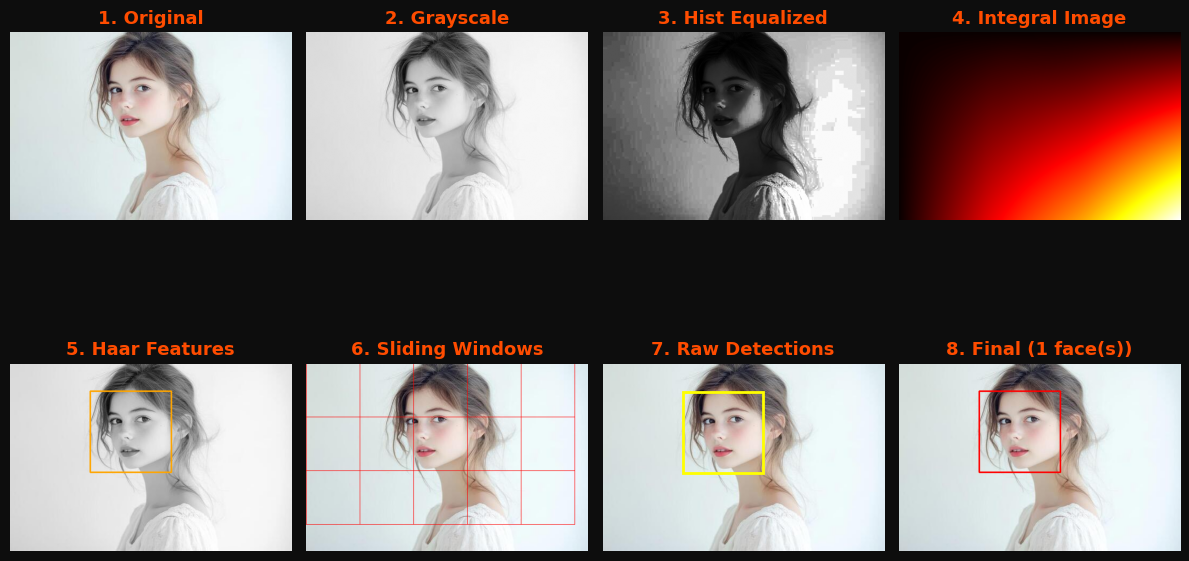

In [6]:
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hist_eq = cv2.equalizeHist(gray)
integral_img = cv2.integral(gray)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6)

final_img = img_rgb.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(final_img, (x, y), (x+w, y+h), (255, 0, 0), 2)

sliding_img = img_rgb.copy()
h, w = gray.shape
for y in range(0, h-100, 100):
    for x in range(0, w-100, 100):
        cv2.rectangle(sliding_img, (x,y), (x+100,y+100), (255,0,0), 1)

haar_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
for (x, y, w, h) in faces:
    cv2.rectangle(haar_vis, (x, y), (x+w, y+h), (255,165,0), 2)

plt.figure(figsize=(12,8))

plt.subplot(2,4,1)
plt.title("1. Original")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(2,4,2)
plt.title("2. Grayscale")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(2,4,3)
plt.title("3. Hist Equalized")
plt.imshow(hist_eq, cmap='gray')
plt.axis('off')

plt.subplot(2,4,4)
plt.title("4. Integral Image")
plt.imshow(integral_img, cmap='hot')
plt.axis('off')

plt.subplot(2,4,5)
plt.title("5. Haar Features")
plt.imshow(haar_vis)
plt.axis('off')

plt.subplot(2,4,6)
plt.title("6. Sliding Windows")
plt.imshow(sliding_img)
plt.axis('off')

plt.subplot(2,4,7)
plt.title("7. Raw Detections")
plt.imshow(img_rgb)
for (x, y, w, h) in faces:
    plt.gca().add_patch(
        plt.Rectangle((x,y), w, h, fill=False, edgecolor='yellow', linewidth=2)
    )
plt.axis('off')

plt.subplot(2,4,8)
plt.title(f"8. Final ({len(faces)} face(s))")
plt.imshow(final_img)
plt.axis('off')

plt.tight_layout()
plt.show()